# Объединим датасеты

Мы получили датасет путем скрапинга и по апи. Теперь соединим их таким образом, чтобы объявление находилось сразу в обоих датасетах


In [655]:
import pandas as pd
import numpy as np

In [656]:
df_api = pd.read_csv('new_data.csv')
df_skraping = pd.read_csv('checkpoint_4400.csv')

In [657]:
df_api.head(3)

,url,make,model,year,recalls_count,complaints_count,injuries,deaths,has_fire,has_crash,overall_rating,front_crash_rating,side_crash_rating,rollover_rating,manufacturer_country,model_exists
0,https://auto.drom.ru/perm/hyundai/elantra/4754...,hyundai,elantra,2020,3,222,15,2,6,20,4,4,4,4,MEXICO,True
1,https://auto.drom.ru/vsevolozhsk/toyota/camry/...,toyota,camry,2019,6,361,18,0,1,21,5,5,5,5,UNITED STATES (USA),True
2,https://auto.drom.ru/kovrov/hyundai/accent/441...,hyundai,accent,2007,3,88,19,0,1,11,Not Rated,Not Rated,Not Rated,Not Rated,MEXICO,True


In [658]:
df_api.shape

(1467, 16)

In [659]:
df_skraping.head(3)

,url,title,year,city,make,model,price,engine,transmission,mileage,drive,body,color,wheel,hp,description
0,https://auto.drom.ru/ekaterinburg/toyota/crown...,"Продажа Toyota Crown, 1990 год в Екатеринбурге",1990.0,ekaterinburg,toyota,crown,500000.0,"бензин, 2.0 л",АКПП,280000.0,задний,седан,синий,правый,170.0,: Если машина интересна и готовы взять её под ...
1,https://auto.drom.ru/perm/hyundai/elantra/4754...,"Продажа Hyundai Elantra, 2020 год в Перми",2020.0,perm,hyundai,elantra,689000.0,"бензин, 2.0 л",АКПП,88000.0,передний,седан,серый,левый,150.0,: Федеральная сеть автосалонов Crystal Motors ...
2,https://auto.drom.ru/vsevolozhsk/toyota/camry/...,"Продажа Toyota Camry, 2019 год во Всеволожске",2019.0,vsevolozhsk,toyota,camry,1600000.0,"бензин, 2.0 л",АКПП,400000.0,передний,седан,белый,левый,150.0,: Машина ходовое вложение не требует Город : В...


In [660]:
df_skraping.shape

(4398, 16)

In [661]:
df = pd.merge(df_api, df_skraping, on = ['url', 'make', 'model', 'year'], how = 'inner')

In [662]:
df.shape

(1467, 28)

In [663]:
df.sample(3)

,url,make,model,year,recalls_count,complaints_count,injuries,deaths,has_fire,has_crash,...,price,engine,transmission,mileage,drive,body,color,wheel,hp,description
1136,https://auto.drom.ru/anzhero-sudzhensk/mazda/m...,mazda,mazda3,2007,3,222,28,0,3,28,...,560000.0,"бензин, 1.6 л",механика,249000.0,передний,хэтчбек 5 дв.,серебристый,левый,105.0,: Кузов в отличном состоянии. Двигатель не дым...
1029,https://auto.drom.ru/krasnodar/mazda/cx-7/5059...,mazda,cx-7,2008,5,191,2,0,9,3,...,760000.0,"бензин, 2.3 л",АКПП,300000.0,4WD,NaN,черный,левый,238.0,": авто на полном ходу , машиной пользовались м..."
653,https://auto.drom.ru/astrahan/volkswagen/passa...,volkswagen,passat,2008,4,174,2,0,6,3,...,700000.0,"дизель, 2.0 л",механика,510500.0,4WD,универсал,синий,левый,140.0,: Собственник один. Владею с 2011года.Был в ДТ...


In [664]:
df.duplicated().sum()

np.int64(0)

на всякий проверяем на дубликаты, но их и не будет, так как мы при сборе датасета их удаляли

In [665]:
df.dtypes

,0
url,object
make,object
model,object
year,int64
recalls_count,int64
complaints_count,int64
injuries,int64
deaths,int64
has_fire,int64
has_crash,int64


Давайте приведем все к корректным типам данных. В целом, почти все типы данных корректны, только в столбцах, связанных с рейтингом должен быть float, а не object. Такое возникает потому что пропуск прописывается фразой 'Not Rated'. Давайте все такие значения заменим на Nan

In [666]:
print('Количество Not Rated в overall_rating', (df['overall_rating'] == 'Not Rated').sum())
print('Количество Nan в overall_rating', df['overall_rating'].isna().sum())
print('Количество Not Rated в front_crash_rating', (df['front_crash_rating'] == 'Not Rated').sum())
print('Количество Nan в front_crash_rating', df['front_crash_rating'].isna().sum())
print('Количество Not Rated в side_crash_rating', (df['side_crash_rating'] == 'Not Rated').sum())
print('Количество Nan в side_crash_rating', df['side_crash_rating'].isna().sum())
print('Количество Not Rated в rollover_rating', (df['rollover_rating'] == 'Not Rated').sum())
print('Количество Nan в rollover_rating', df['rollover_rating'].isna().sum())

Количество Not Rated в overall_rating 785
Количество Nan в overall_rating 87
Количество Not Rated в front_crash_rating 781
Количество Nan в front_crash_rating 87
Количество Not Rated в side_crash_rating 782
Количество Nan в side_crash_rating 87
Количество Not Rated в rollover_rating 583
Количество Nan в rollover_rating 87


In [667]:
df.loc[df['overall_rating'] == 'Not Rated', 'overall_rating'] = np.nan
df.loc[df['front_crash_rating'] == 'Not Rated', 'front_crash_rating'] = np.nan
df.loc[df['side_crash_rating'] == 'Not Rated', 'side_crash_rating'] = np.nan
df.loc[df['rollover_rating'] == 'Not Rated', 'rollover_rating'] = np.nan

In [668]:
print('Количество Nan в overall_rating', df['overall_rating'].isna().sum())
print('Количество Nan в front_crash_rating', df['front_crash_rating'].isna().sum())
print('Количество Nan в side_crash_rating', df['side_crash_rating'].isna().sum())
print('Количество Nan в rollover_rating', df['rollover_rating'].isna().sum())

Количество Nan в overall_rating 872
Количество Nan в front_crash_rating 868
Количество Nan в side_crash_rating 869
Количество Nan в rollover_rating 670


In [669]:
df['overall_rating'] = pd.to_numeric(df['overall_rating'])
df['front_crash_rating'] = pd.to_numeric(df['front_crash_rating'])
df['side_crash_rating'] = pd.to_numeric(df['side_crash_rating'])
df['rollover_rating'] = pd.to_numeric(df['rollover_rating'])

Поменяли на Nan, видим, что очень большое количество пропусков в этих столбцах, давайте в целом глянем на все пропуски

# Обработка пропусков

In [670]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1467 entries, 0 to 1466
Data columns (total 28 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   url                   1467 non-null   object 
 1   make                  1467 non-null   object 
 2   model                 1467 non-null   object 
 3   year                  1467 non-null   int64  
 4   recalls_count         1467 non-null   int64  
 5   complaints_count      1467 non-null   int64  
 6   injuries              1467 non-null   int64  
 7   deaths                1467 non-null   int64  
 8   has_fire              1467 non-null   int64  
 9   has_crash             1467 non-null   int64  
 10  overall_rating        595 non-null    float64
 11  front_crash_rating    599 non-null    float64
 12  side_crash_rating     598 non-null    float64
 13  rollover_rating       797 non-null    float64
 14  manufacturer_country  1466 non-null   object 
 15  model_exists         

Вот теперь все супер! Все столбцы имеют корректные типы данных. Теперь будем смотреть на пропуски

# Давайте посмотрим на корреляцию столбцов, принимающих числовые значения


In [671]:
df_numeric = df[['year', 'recalls_count', 'complaints_count', 'injuries', 'deaths', 'has_fire', 'has_crash', 'overall_rating',
                'front_crash_rating', 'side_crash_rating', 'rollover_rating', 'price', 'mileage', 'hp']]
df_numeric.head(5)

,year,recalls_count,complaints_count,injuries,deaths,has_fire,has_crash,overall_rating,front_crash_rating,side_crash_rating,rollover_rating,price,mileage,hp
0,2020,3,222,15,2,6,20,4.0,4.0,4.0,4.0,689000.0,88000.0,150.0
1,2019,6,361,18,0,1,21,5.0,5.0,5.0,5.0,1600000.0,400000.0,150.0
2,2007,3,88,19,0,1,11,NaN,NaN,NaN,NaN,450000.0,238000.0,102.0
3,2004,0,33,15,0,2,11,NaN,NaN,NaN,NaN,495000.0,NaN,102.0
4,2004,5,182,26,0,2,24,NaN,NaN,NaN,NaN,270000.0,279123.0,105.0


In [672]:
import plotly.express as px

corr_matrix = df_numeric.corr(method = 'spearman')
fig = px.imshow(corr_matrix, text_auto='.2f', color_continuous_scale='RdBu', title = 'Корреляция признаков между собой')
fig.show()



Видим, что корреляция year и mileage -0.67 - это обозначает обратную зависимость, то есть когда увеличивается одна переменная, другая уменьшается. То есть уменьшение года сопровождается увеличением пробега

year и price имеют положиетльную зависимость, когда увеличивается одна переменная, увеличивается и вторая. Получается, что чем новее машина, тем больше ее цена


Видим еще квадратик голубой в левом верхнем углу. Как раз все эти признаки имеют положительную зависимость. Они все относятся к критериям безопасности и качества авто

Более того видим положительную зависимость между жалобами и пострадавшими

#  Univariant Analysis

Теперь давайте посмотрим как у нас выглядит каждый признак


**url** - ссылка на объявление, в нашем случае уникальный идентификатор автомобиля. Именно по ссылке производился весь сбор данных в скрапинге


**1.make** - производитель (марка) автомобиля

**2.model** - модель автомобиля

**3.year** - год выпуска конкретного автомобиля

**4.recalls_count** - количество отзывных компаний на конкретную модель автомобиля

**5.complaints_count** - количество жалоб на конкретную модель

**6.injuries** - количесвтво травмы, полученные при использовании данной модели авто

**7.deaths** - колчество умерших, при использовании данной модели авто

**8.has_fire** -колчество возгораний данной модели авто

**9.has_crash** - количество аварий данной модели авто

**10.overall_rating** - (???)

**11.front_crash_rating** - (???)

**12.side_crash_rating** - (???)

**13.rollover_rating** - (???)

**14.manufacturer_country** - страна выпуска модели автомобиля

**15.model_exists** - маркер о существовании такой модели автомобиля. В нашем датасете все автомобили имеют значение True

**16.title** - заголовок объявления о продаже конкретного авто

**17.city** - город, в котором осуществляется продажа конкретного авто

**18.price** - цена конкретного автомобиля

**19.engine** - тип топлива, объем двигателя и дополнительное оборудование

**20.transmission** - тип коробки передач у конкретного автомобиля

**21.mileage** - пробег конкретного автомобиля

**22.drive** - тип привода конкретного автомобиля

**23.body** - тип кузова конкретного автомобиля

**24.color** - цвет конкретного автомобиля

**25.wheel** - расположение руля в конкретном автомобиле

**26.hp** - количество лошадиных сил конкретного автомобиля

**27.description** - описание автомобиля, взятое из объявления

часто содержит очень полезную дополнительную информацию, источник продажи (собственник или автосалон) и остальные нюансы(количество собственников, дтп)



Давайте теперь посмотрим на каждый признак по отдельности


**1.make** - производитель (марка) автомобиля

давайте в целом посмотрим, сколько объявлений о продаже приходится на конкретные марки авто

In [673]:
make_pivot = pd.pivot_table(df, values = 'url', index = 'make', aggfunc = 'count').sort_values(by = 'url')

Text(0, 0.5, 'Количество объявлений о продаже')

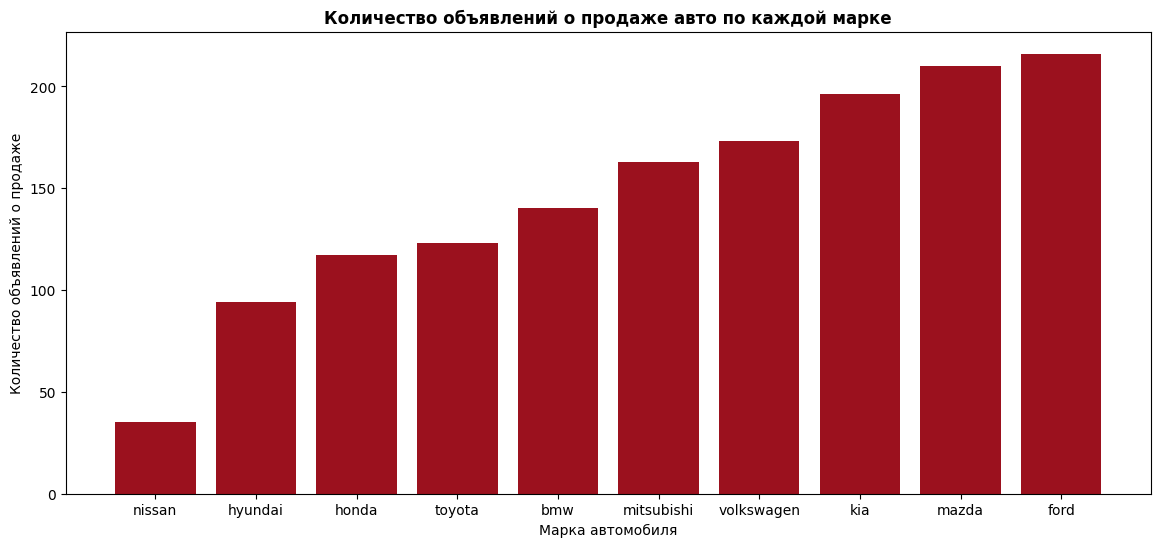

In [674]:
import matplotlib.pyplot as plt

plt.figure(figsize = (14, 6))
plt.bar(make_pivot.index, make_pivot['url'], color = '#9B111E')


plt.title('Количество объявлений о продаже авто по каждой марке', fontweight = 'bold')
plt.xlabel('Марка автомобиля')
plt.ylabel('Количество объявлений о продаже')

КАКОЙ-ТО ТЕКСТИК

2.model - модель автомобиля

здесь будем рассматривать количество различных моделей авто у одного производителя (марки)

In [675]:
model_pivot = pd.pivot_table(df, values = 'model', index = 'make', aggfunc = 'nunique').sort_values(by = 'model')

Text(0, 0.5, 'Количество моделей')

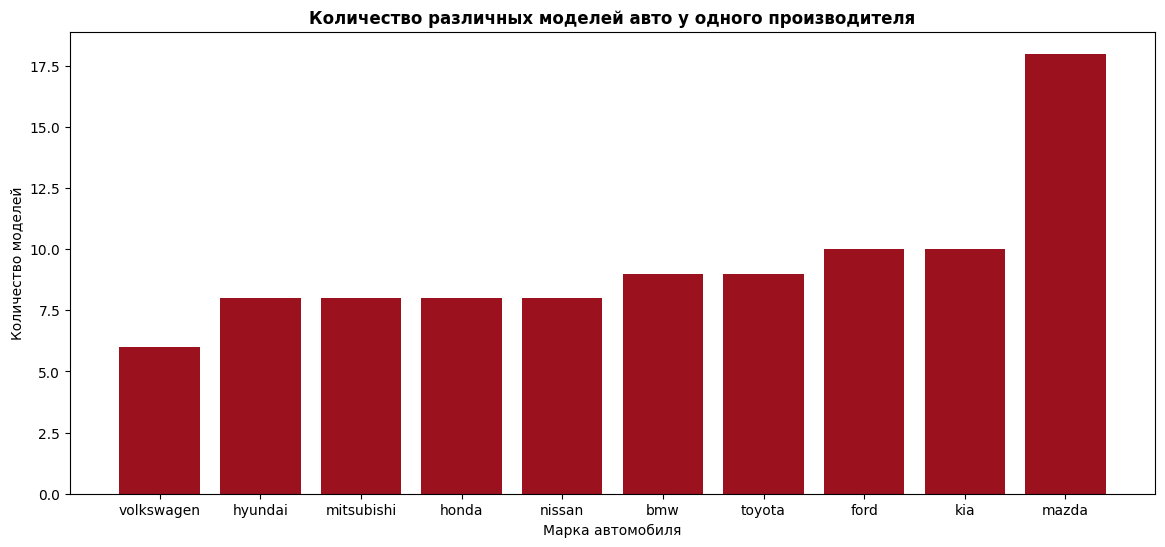

In [676]:
import matplotlib.pyplot as plt

plt.figure(figsize = (14, 6))
plt.bar(model_pivot.index, model_pivot['model'], color = '#9B111E')


plt.title('Количество различных моделей авто у одного производителя', fontweight = 'bold')
plt.xlabel('Марка автомобиля')
plt.ylabel('Количество моделей')

ТУТ КАКОЙ-ТО ТЕКСТ

3.year - год выпуска конкретного автомобиля

давайте посмотрим как автомобили из нашего датасета распределены по годам производства

In [677]:
years_pivot = pd.pivot_table(df, values = 'url', index = 'year', aggfunc = 'count')

Text(0, 0.5, 'Количество автомобилей')

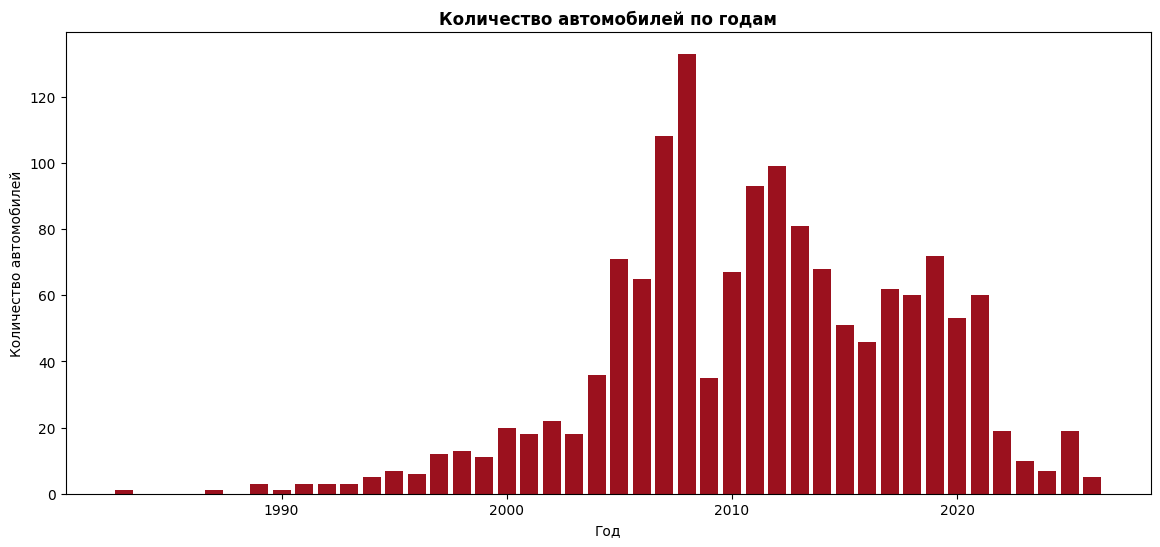

In [678]:
plt.figure(figsize = (14, 6))
plt.bar(years_pivot.index, years_pivot['url'], color = '#9B111E')


plt.title('Количество автомобилей по годам', fontweight = 'bold')
plt.xlabel('Год')
plt.ylabel('Количество автомобилей')

КАКОЙ-ТО ТЕКСТИК ПРО ЭТО ВСЕ

4.recalls_count - количество отзывных компаний на конкретную модель автомобиля

In [679]:
recalls_table = df['recalls_count'].value_counts().sort_index()
recalls_table

,count
recalls_count,
0,133
1,185
2,195
3,209
4,133
5,143
6,139
7,93
8,54


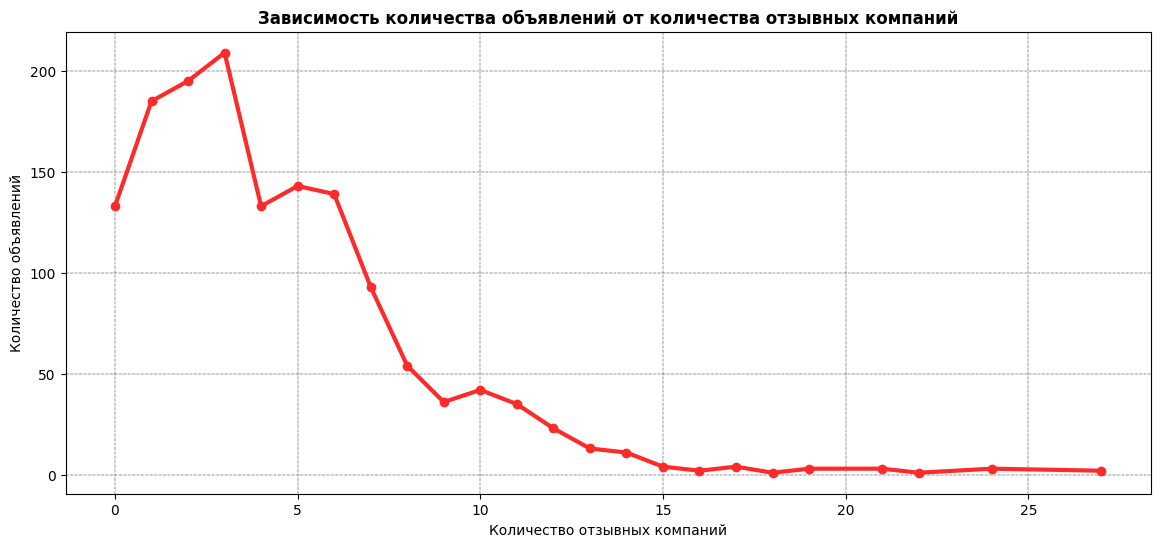

In [680]:
plt.figure(figsize = (14, 6))
plt.plot(recalls_table.index, recalls_table, color = '#FF2B2B', linewidth = 3, marker = 'o')
plt.title('Зависимость количества объявлений от количества отзывных компаний', fontweight = 'bold')
plt.xlabel('Количество отзывных компаний')
plt.ylabel('Количество объявлений')
plt.grid(axis = 'both', color = 'black', linestyle = '-.', linewidth = 0.3)

КАКОЙ-ТО ТЕКСТ НАДО НАПИСАТЬ

5.complaints_count - количество жалоб на конкретную модель

In [681]:
complaints_table = pd.cut(df['complaints_count'], bins = [0, 50, 100, 150, 200, 500, 1000, 2000, 3000, 4000, 6000],
    labels = ['до 50', '50 – 100', '100 – 150', '150 – 200', '200 – 500', '500 – 1000', '1000 - 2000', '2000 - 3000', '3000 - 4000', '4000+'])
complaints_table = complaints_table.value_counts().sort_index()

Text(0, 0.5, 'Количество автомобилей')

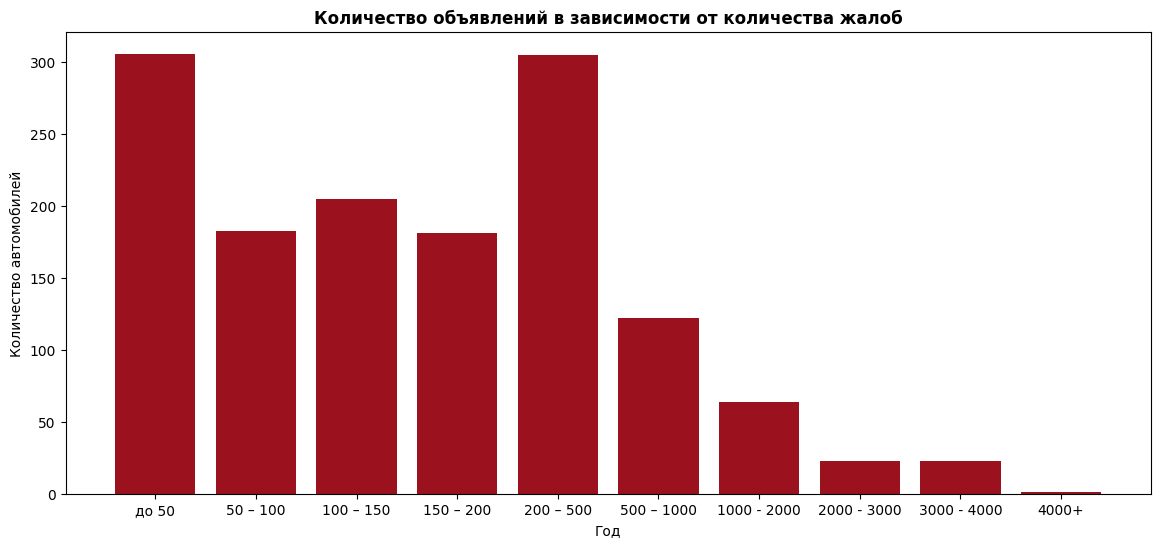

In [682]:
plt.figure(figsize = (14, 6))
plt.bar(complaints_table.index, complaints_table, color = '#9B111E')


plt.title('Количество объявлений в зависимости от количества жалоб', fontweight = 'bold')
plt.xlabel('Год')
plt.ylabel('Количество автомобилей')

КАКОЙ-ТО ОЧЕРЕНДОЙ ТЕКСТ

6.injuries - количесвтво травмы, полученные при использовании данной модели авто

7.deaths - колчество умерших, при использовании данной модели авто

Рассмотрим как выглядит распределение этих признаков

In [683]:
injuries_table = df['injuries'].value_counts().sort_index()
deaths_table = df['deaths'].value_counts().sort_index()
deaths_table

,count
deaths,
0,1157
1,182
2,50
3,39
4,5
5,20
6,2
8,2
9,4


([<matplotlib.axis.XTick at 0x78b9a60fa5d0>,
 [Text(0, 0, '0'),
  Text(1, 0, '1'),
  Text(2, 0, '2'),
  Text(3, 0, '3'),
  Text(4, 0, '4'),
  Text(5, 0, '5'),
  Text(6, 0, '6'),
  Text(7, 0, '7'),
  Text(8, 0, '8'),
  Text(9, 0, '9'),
  Text(10, 0, '10'),
  Text(11, 0, '11'),
  Text(12, 0, '12'),
  Text(13, 0, '13'),
  Text(14, 0, '14'),
  Text(15, 0, '15'),
  Text(16, 0, '16'),
  Text(17, 0, '17'),
  Text(18, 0, '18'),
  Text(19, 0, '19')])

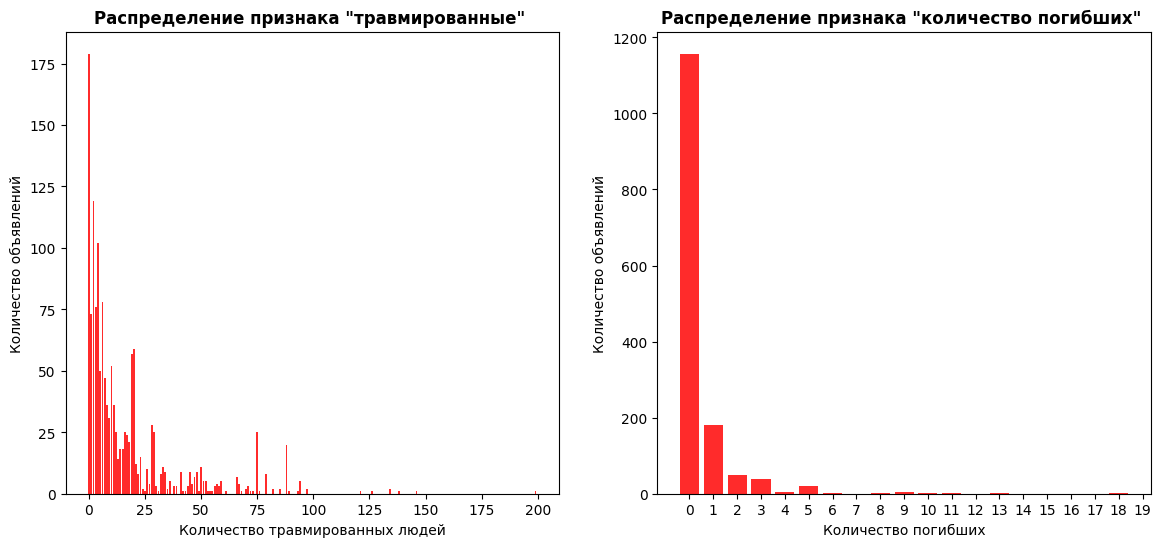

In [684]:
plt.figure(figsize = (14, 6))

plt.subplot(1, 2, 1)
plt.bar(injuries_table.index, injuries_table, color = '#FF2B2B')
plt.title('Распределение признака "травмированные" ', fontweight = 'bold')
plt.ylabel('Количество объявлений')
plt.xlabel('Количество травмированных людей')

plt.subplot(1, 2, 2)
plt.bar(deaths_table.index, deaths_table, color = '#FF2B2B')
plt.title('Распределение признака "количество погибших" ', fontweight = 'bold')
plt.ylabel('Количество объявлений')
plt.xlabel('Количество погибших')
plt.xticks(range(0, 20))


КАКОЙ-ТО ВЫВОД: УМИРАЮТ В РАЗЫ МЕНЬШЕ ЧЕМ ТРАВМИРУЮТСЯ

Теперь рассмотрим наши рейтинговые признаки

10.overall_rating - (???)

11.front_crash_rating - (???)

12.side_crash_rating - (???)

13.rollover_rating - (???)

In [685]:
overall_rating_table = df['overall_rating'].value_counts().sort_index()
front_crash_rating_table = df['front_crash_rating'].value_counts().sort_index()
side_crash_rating_table = df['side_crash_rating'].value_counts().sort_index()
rollover_rating_table = df['rollover_rating'].value_counts().sort_index()

([<matplotlib.axis.XTick at 0x78b9a5e77fe0>,
 [Text(0, 0, '0'),
  Text(1, 0, '1'),
  Text(2, 0, '2'),
  Text(3, 0, '3'),
  Text(4, 0, '4'),
  Text(5, 0, '5')])

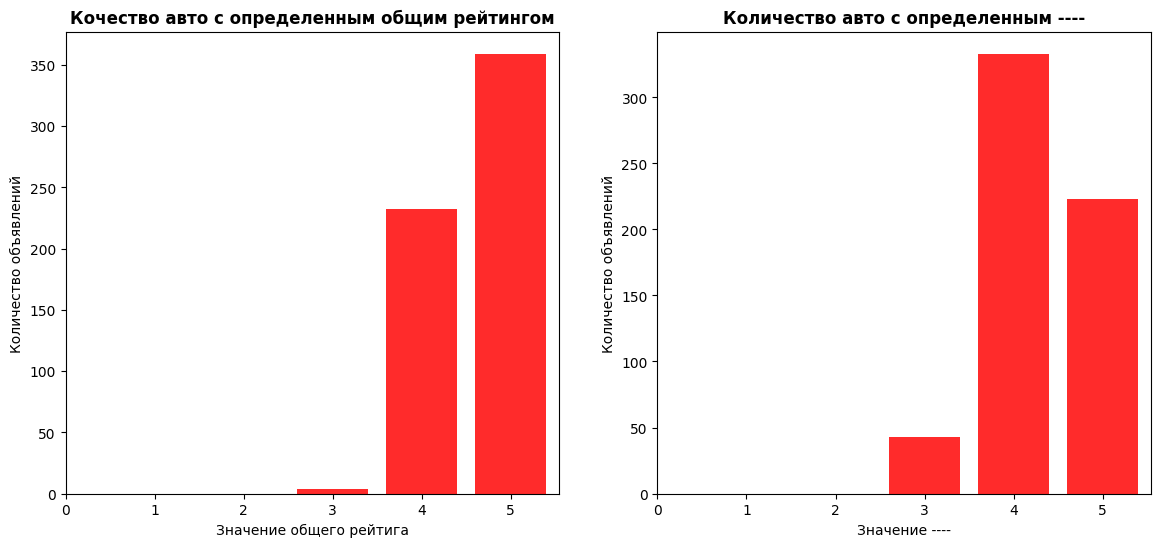

In [686]:
plt.figure(figsize = (14, 6))

plt.subplot(1, 2, 1)
plt.bar(overall_rating_table.index, overall_rating_table, color = '#FF2B2B')
plt.title('Кочество авто с определенным общим рейтингом', fontweight = 'bold')
plt.ylabel('Количество объявлений')
plt.xlabel('Значение общего рейтига')
plt.xticks(range(0, 6))

plt.subplot(1, 2, 2)
plt.bar(front_crash_rating_table.index, front_crash_rating_table, color = '#FF2B2B')
plt.title('Количество авто с определенным ----', fontweight = 'bold')
plt.ylabel('Количество объявлений')
plt.xlabel('Значение ----')
plt.xticks(range(0, 6))


([<matplotlib.axis.XTick at 0x78b9a5d4de50>,
 [Text(0, 0, '0'),
  Text(1, 0, '1'),
  Text(2, 0, '2'),
  Text(3, 0, '3'),
  Text(4, 0, '4'),
  Text(5, 0, '5')])

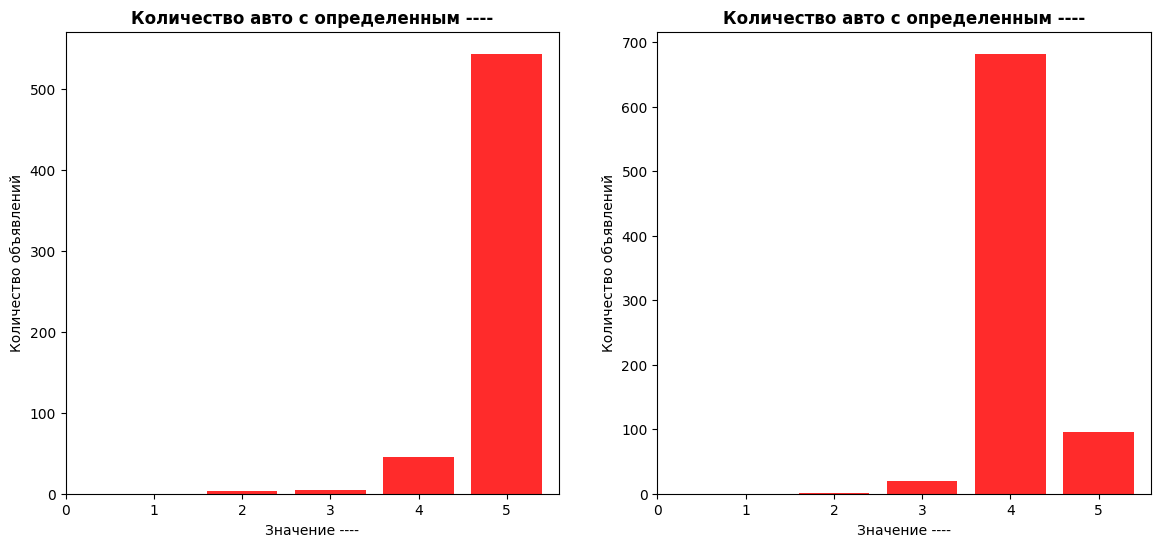

In [687]:
plt.figure(figsize = (14, 6))

plt.subplot(1, 2, 1)
plt.bar(side_crash_rating_table.index, side_crash_rating_table, color = '#FF2B2B')
plt.title('Количество авто с определенным ----', fontweight = 'bold')
plt.ylabel('Количество объявлений')
plt.xlabel('Значение ----')
plt.xticks(range(0, 6))

plt.subplot(1, 2, 2)
plt.bar(rollover_rating_table.index, rollover_rating_table, color = '#FF2B2B')
plt.title('Количество авто с определенным ----', fontweight = 'bold')
plt.ylabel('Количество объявлений')
plt.xlabel('Значение ----')
plt.xticks(range(0, 6))

КАКОЙ-ТО ВЫВОД ПО 4 РЕЙТИНГОВЫМ ПАРАМЕТРАМ

14.manufacturer_country - страна выпуска модели автомобиля

Давайте посмотрим какое у нас распределение автомобилей по странам производства

In [688]:
country_table = pd.pivot_table(df, values = 'url', index = 'manufacturer_country', aggfunc = 'count')
country_table

,url
manufacturer_country,
GERMANY,312
JAPAN,210
MEXICO,129
SLOVAKIA,196
UNITED STATES (USA),619


Text(0, 0.5, 'Количество автомобилей(объявлений)')

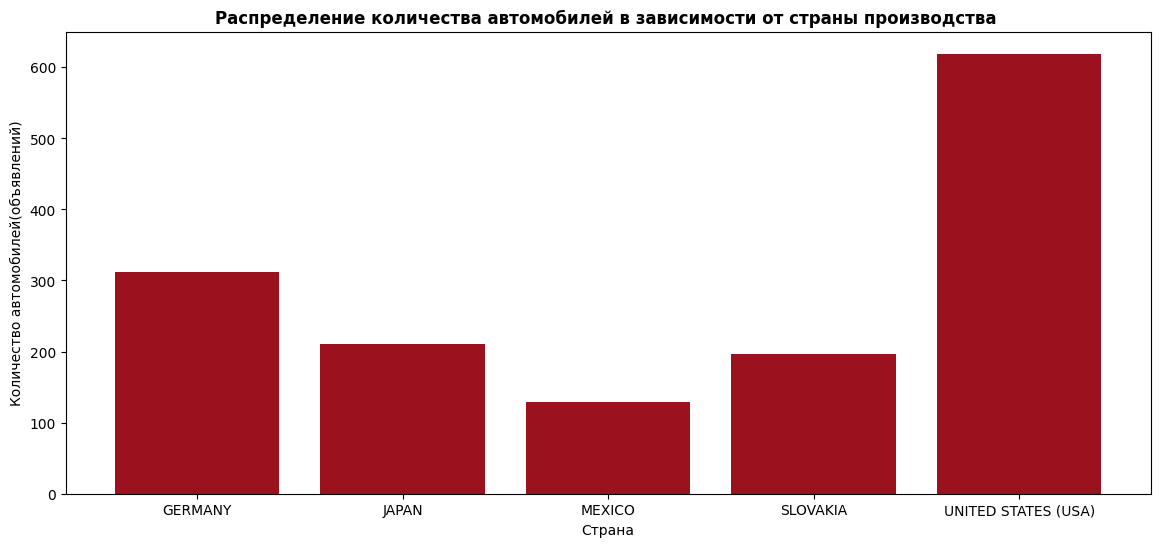

In [689]:
plt.figure(figsize = (14, 6))
plt.bar(country_table.index, country_table['url'], color = '#9B111E')


plt.title('Распределение количества автомобилей в зависимости от страны производства ', fontweight = 'bold')
plt.xlabel('Страна')
plt.ylabel('Количество автомобилей(объявлений)')

КАКОЙ-ТО ВЫВОД АМЕРИКА ТОП ПОТОМ ГЕРМАНИЯ

15.model_exists - маркер о существовании такой модели автомобиля. В нашем датасете все автомобили имеют значение True. Поэтому мы будем просто удалять этот столбец


In [690]:
df['model_exists'].unique()

array([ True])

16.title - заголовок объявления о продаже конкретного авто
это все заголовки, которые прописывает автор объявления при их создании, сожержит общую текстовую информацию об объявлении

In [691]:
df['title'].sample(5)

,title
1200,"Продажа Mazda CX-5, 2025 год в Москве"
1403,"Продажа Mitsubishi Outlander, 2015 год в Новос..."
324,"Продажа Toyota Corolla, 2013 год в Волгограде"
685,"Продажа Honda Accord, 2008 год в Новосибирске"
698,"Продажа Honda Fit, 2013 год в Чите"


17.city - город, в котором осуществляется продажа конкретного авто

In [692]:
city_pivot = pd.pivot_table(df, values = 'url', index = 'city', aggfunc = 'count')

Text(0, 0.5, 'Количество автомобилей(объявлений)')

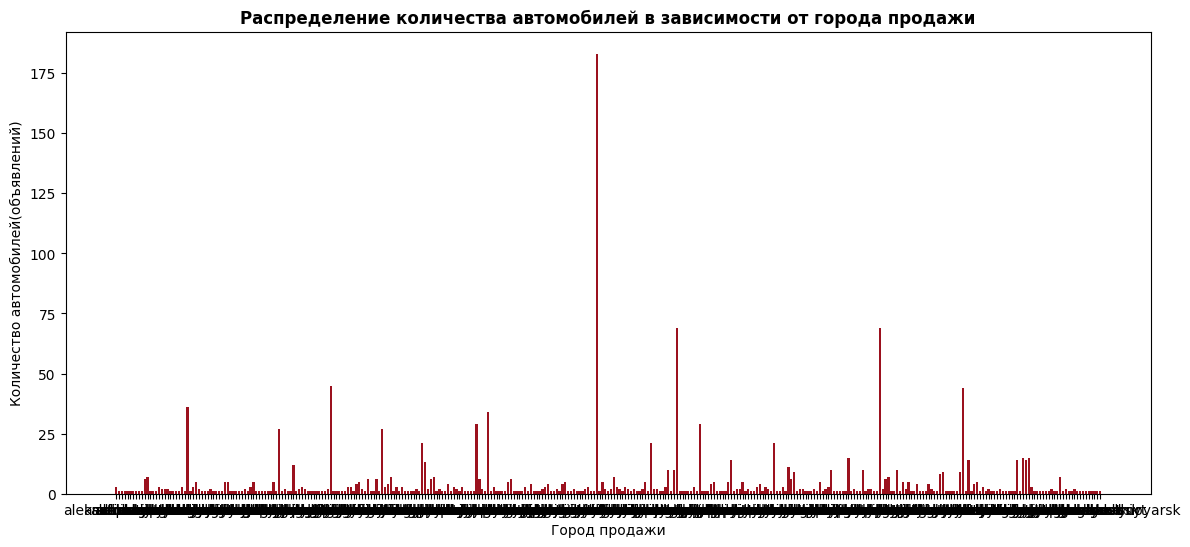

In [693]:
plt.figure(figsize = (14, 6))
plt.bar(city_pivot.index, city_pivot['url'], color = '#9B111E')


plt.title('Распределение количества автомобилей в зависимости от города продажи', fontweight = 'bold')
plt.xlabel('Город продажи')
plt.ylabel('Количество автомобилей(объявлений)')

Ой, что-то огромное, давайте для наглядности возьмем 20 городов, с наибольшим количеством объявлений

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19],
 [Text(0, 0, 'perm'),
  Text(1, 0, 'vologda'),
  Text(2, 0, 'ufa'),
  Text(3, 0, 'simferopol'),
  Text(4, 0, 'volgograd'),
  Text(5, 0, 'voronezh'),
  Text(6, 0, 'nizhniy-novgorod'),
  Text(7, 0, 'kazan'),
  Text(8, 0, 'rostov-na-donu'),
  Text(9, 0, 'chelyabinsk'),
  Text(10, 0, 'irkutsk'),
  Text(11, 0, 'krasnodar'),
  Text(12, 0, 'omsk'),
  Text(13, 0, 'krasnoyarsk'),
  Text(14, 0, 'barnaul'),
  Text(15, 0, 'tyumen'),
  Text(16, 0, 'ekaterinburg'),
  Text(17, 0, 'novosibirsk'),
  Text(18, 0, 'spb'),
  Text(19, 0, 'moscow')])

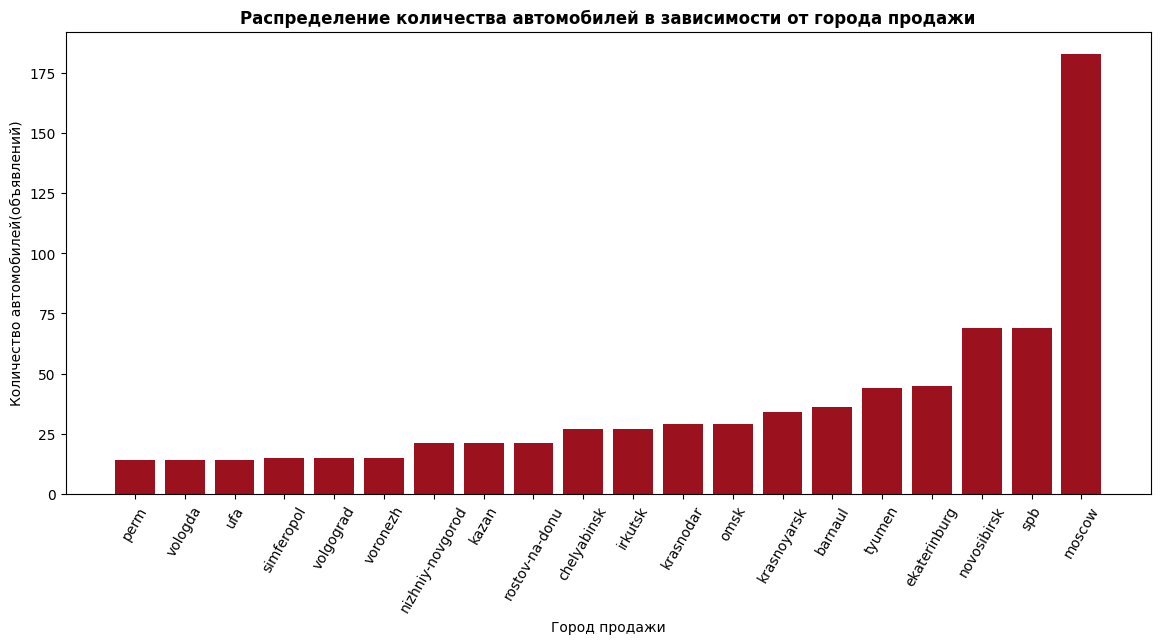

In [694]:
city_pivot = city_pivot.sort_values(by = 'url').tail(20)
plt.figure(figsize = (14, 6))
plt.bar(city_pivot.index, city_pivot['url'], color = '#9B111E')

plt.title('Распределение количества автомобилей в зависимости от города продажи', fontweight = 'bold')
plt.xlabel('Город продажи')
plt.ylabel('Количество автомобилей(объявлений)')
plt.xticks(rotation = 60)

КАКОЙ_ТО ТЕКСТ

18.price - цена конкретного автомобиля

In [695]:
price_table = pd.cut(df['price'], bins = [0, 500000, 1000000, 2000000, 4000000, 6000000, 10000000, 4000000000],
    labels = ['до 500.000', '500.000 – 1.000.000', '1.000.000 – 2.000.000', '2.000.000 – 4.000.000', '4.000.000 – 6.000.000',
              '6.000.000 – 10.000.000', '10.000.000+'])
price_table = price_table.value_counts().sort_index()

([0, 1, 2, 3, 4, 5, 6],
 [Text(0, 0, 'до 500.000'),
  Text(1, 0, '500.000 – 1.000.000'),
  Text(2, 0, '1.000.000 – 2.000.000'),
  Text(3, 0, '2.000.000 – 4.000.000'),
  Text(4, 0, '4.000.000 – 6.000.000'),
  Text(5, 0, '6.000.000 – 10.000.000'),
  Text(6, 0, '10.000.000+')])

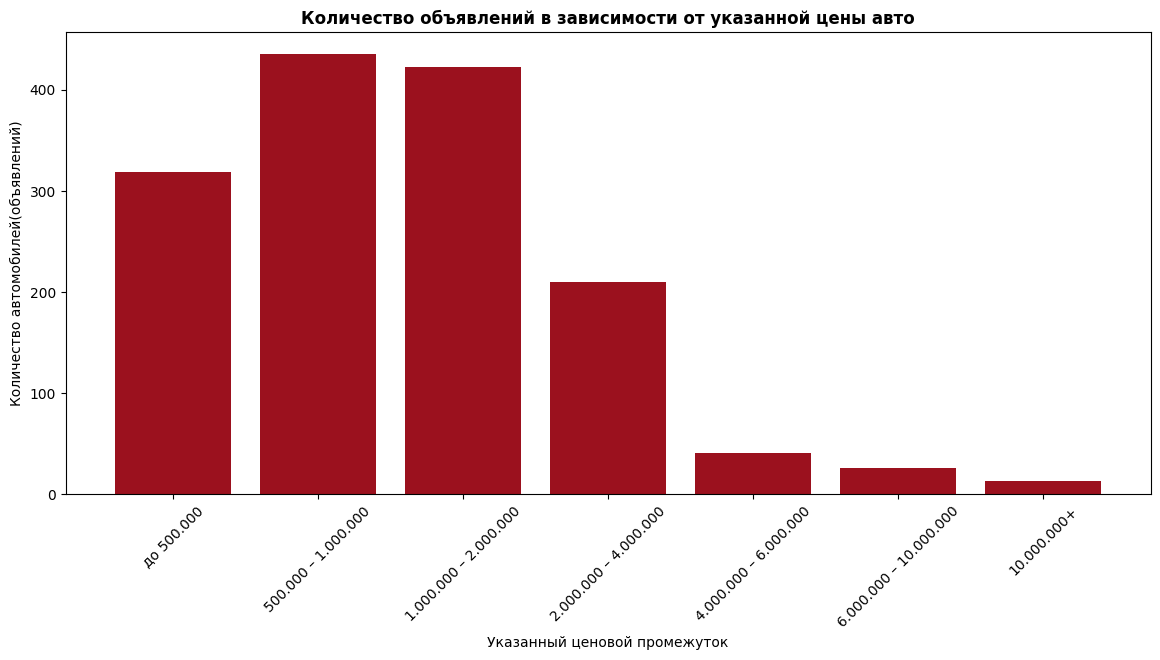

In [696]:
plt.figure(figsize = (14, 6))
plt.bar(price_table.index, price_table, color = '#9B111E')

plt.title('Количество объявлений в зависимости от указанной цены авто', fontweight = 'bold')
plt.xlabel('Указанный ценовой промежуток')
plt.ylabel('Количество автомобилей(объявлений)')
plt.xticks(rotation = 45)

КАКОЙ-ТО ВЫВОД: НУ МЫ БЕДНЫЕ И МАШИН ПОДЕШЕВЛЕ СИЛЬНО БОЛЬШЕ


19.engine - тип топлива, объем двигателя и дополнительное оборудование

In [697]:
df['engine'].unique()

array(['бензин, 2.0 л', 'бензин, 1.5 л', 'бензин, 1.6 л', 'бензин, 3.8 л',
       'бензин, 2.5 л', 'дизель, 2.2 л', 'бензин, 3.0 л', 'бензин, 1.4 л',
       'бензин, 3.5 л', 'бензин, 2.4 л', 'бензин, 2.7 л',
       'бензин, 2.5 л, ГБО', 'бензин, 1.8 л', 'дизель, 2.0 л',
       'дизель, 1.6 л', 'бензин, 1.3 л, ГБО', 'бензин, 2.0 л, ГБО',
       'дизель, 2.5 л', 'бензин, 2.4 л, гибрид, ГБО', '1.8 л',
       'бензин, 5.0 л', 'бензин, 2.5 л, гибрид', 'бензин, 1.6 л, гибрид',
       'бензин, 1.2 л', 'бензин, 1.8 л, гибрид', 'бензин, 1.3 л', '2.0 л',
       'бензин, 1.6 л, ГБО', 'бензин, 1.0 л', 'бензин, 1.5 л, ГБО',
       'бензин, 3.3 л', 'бензин, 1.4 л, ГБО', 'бензин, 5.7 л',
       'бензин, 3.5 л, ГБО', 'дизель, 4.1 л', 'дизель, 3.0 л',
       'бензин, 3.6 л', 'бензин, 2.3 л', 'бензин, 3.2 л, ГБО', 'электро',
       'бензин, 1.7 л', 'бензин, 3.2 л', 'бензин, 2.0 л, гибрид', nan,
       'бензин, 1.5 л, гибрид', 'бензин, 1.3 л, гибрид', 'дизель, 1.9 л',
       'бензин, 1.8 л, ГБО', 'бензин

Тип топлива принимает значения: бензин, дизель, электро
Также есть дополнительное оборудование машины в виде ГБО

ДОПИСАТЬ ПОТОМ КАК ДОДЕЛАЕМ

20.transmission - тип коробки передач у конкретного автомобиля


In [698]:
transmission_table = pd.pivot_table(df, values = 'url', index = 'transmission', aggfunc = 'count')

Text(0, 0.5, 'Количество автомобилей(объявлений)')

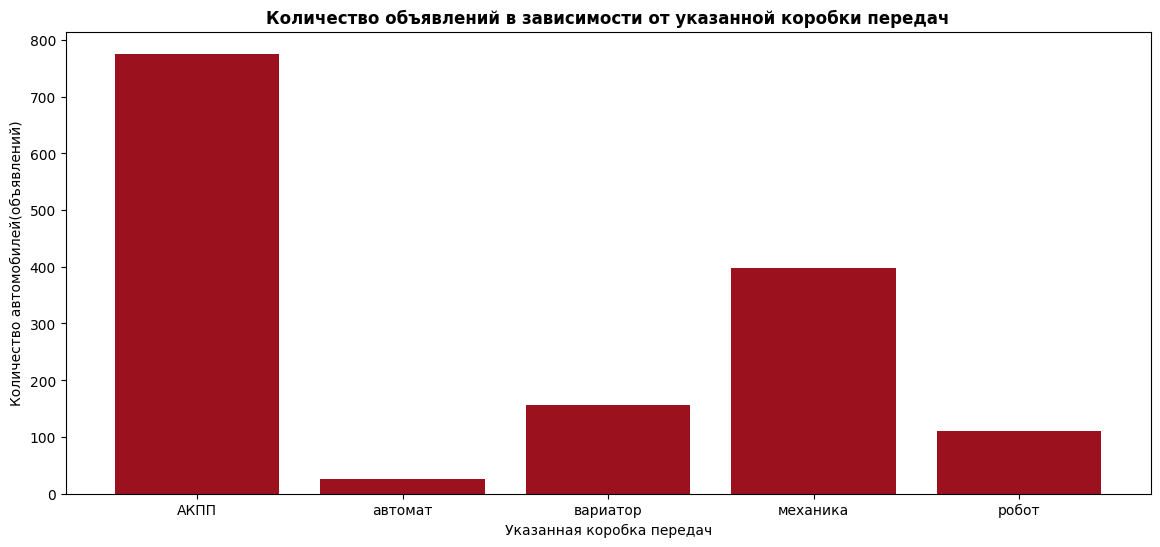

In [699]:
plt.figure(figsize = (14, 6))
plt.bar(transmission_table.index, transmission_table['url'], color = '#9B111E')

plt.title('Количество объявлений в зависимости от указанной коробки передач', fontweight = 'bold')
plt.xlabel('Указанная коробка передач')
plt.ylabel('Количество автомобилей(объявлений)')

АКПП и автомат - это одно и то же, поэтому заменим все значения "автомат" на "АКПП"
НУ И КОНЕЧНО КАКОЙ-ТО ТЕКСТИК

In [700]:
df.loc[df['transmission'] == 'автомат', 'transmission'] = 'АКПП'

In [701]:
pd.pivot_table(df, values = 'url', index = 'transmission', aggfunc = 'count')

,url
transmission,
АКПП,801
вариатор,156
механика,398
робот,111


теперь все супер!

21.mileage - пробег конкретного автомобилят, измеряется в километрах

Посмотрим на распределение пробега,

In [702]:
df['mileage'].min()

1.0

In [703]:
df['mileage'].max()

680000.0

In [704]:
mileage_table = pd.cut(df['mileage'], bins = [0, 10000, 30000, 50000, 100000, 150000, 200000, 300000, 400000, 600000, 1000000],
    labels = ['до 10.000', '10.000 - 30.000', '30.000 - 50.000', '50.000 – 100.000', '100.000 – 150.000', '150.000 – 200.000', '200.000 – 300.000',
              '300.000 – 400.000', '400.000 - 600.000', '600000+'])
mileage_table = mileage_table.value_counts().sort_index()

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'до 10.000'),
  Text(1, 0, '10.000 - 30.000'),
  Text(2, 0, '30.000 - 50.000'),
  Text(3, 0, '50.000 – 100.000'),
  Text(4, 0, '100.000 – 150.000'),
  Text(5, 0, '150.000 – 200.000'),
  Text(6, 0, '200.000 – 300.000'),
  Text(7, 0, '300.000 – 400.000'),
  Text(8, 0, '400.000 - 600.000'),
  Text(9, 0, '600000+')])

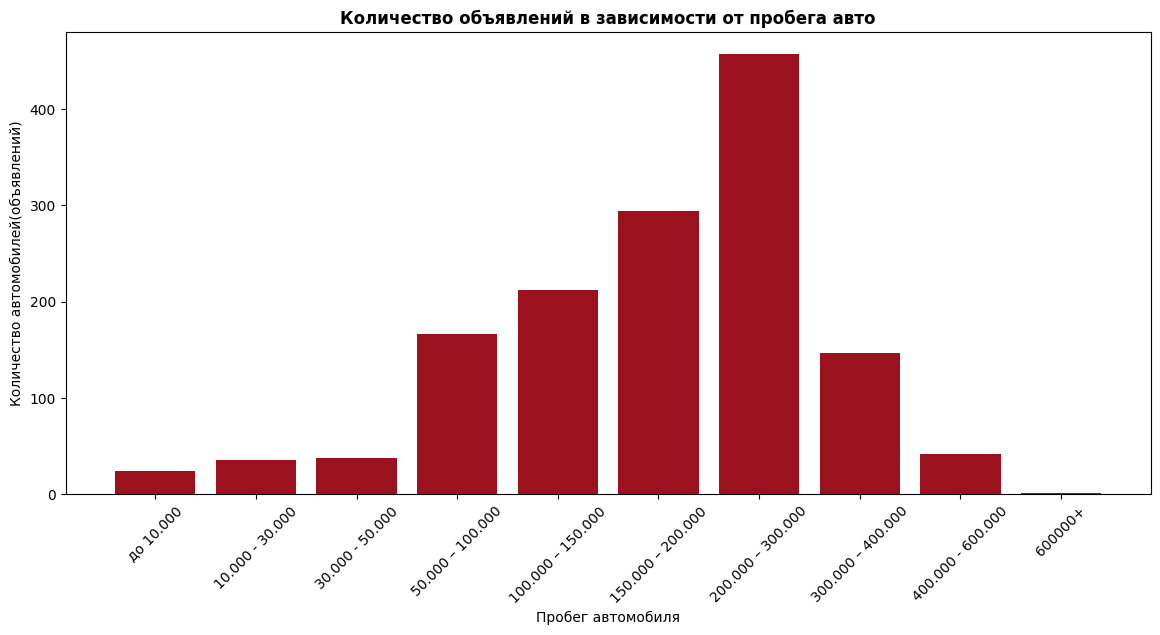

In [705]:
plt.figure(figsize = (14, 6))
plt.bar(mileage_table.index, mileage_table, color = '#9B111E')

plt.title('Количество объявлений в зависимости от пробега авто', fontweight = 'bold')
plt.xlabel('Пробег автомобиля')
plt.ylabel('Количество автомобилей(объявлений)')
plt.xticks(rotation = 45)

КАКОЙ-ТО ВЫВОД

22.drive - тип привода конкретного автомобиля

In [706]:
drive_pivot = pd.pivot_table(df, values = 'url', index = 'drive', aggfunc = 'count')

([0, 1, 2], [Text(0, 0, '4WD'), Text(1, 0, 'задний'), Text(2, 0, 'передний')])

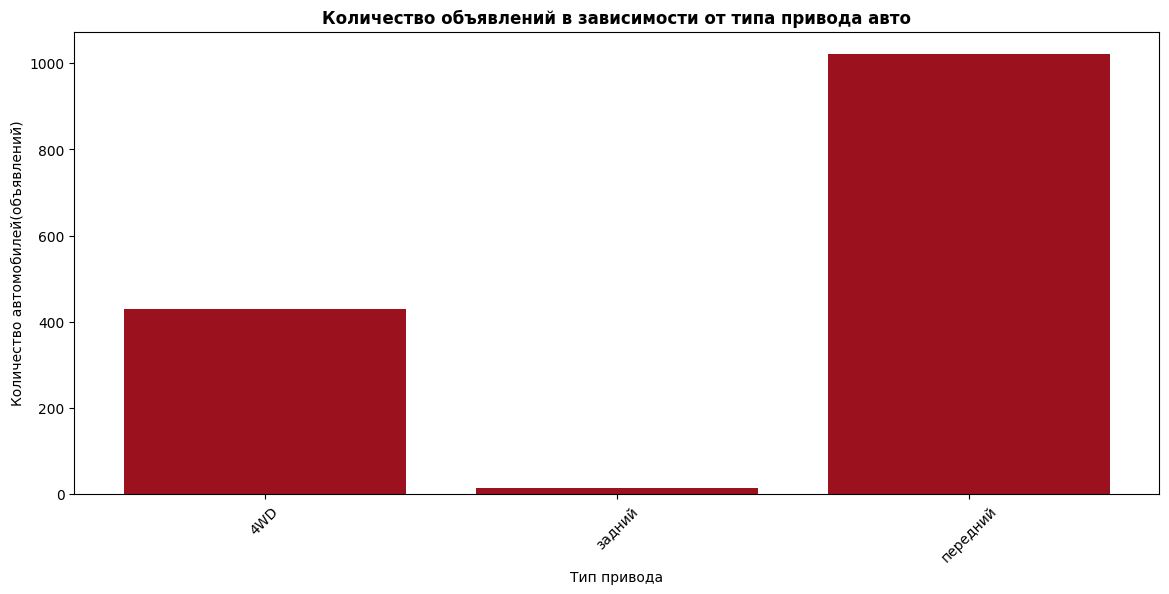

In [707]:
plt.figure(figsize = (14, 6))
plt.bar(drive_pivot.index, drive_pivot['url'], color = '#9B111E')

plt.title('Количество объявлений в зависимости от типа привода авто', fontweight = 'bold')
plt.xlabel('Тип привода')
plt.ylabel('Количество автомобилей(объявлений)')
plt.xticks(rotation = 45)

КАКОЙ-ТО ТЕКСТИК

23.body - тип кузова конкретного автомобиля

In [708]:
body_table = df['body'].value_counts()
body_table

,count
body,
седан,607
хэтчбек 5 дв.,164
джип/suv 5 дв.,104
универсал,53
лифтбек,10
хэтчбек 3 дв.,7
купе,7
открытый,2


([0, 1, 2, 3, 4, 5, 6, 7],
 [Text(0, 0, 'седан'),
  Text(1, 0, 'хэтчбек 5 дв.'),
  Text(2, 0, 'джип/suv 5 дв.'),
  Text(3, 0, 'универсал'),
  Text(4, 0, 'лифтбек'),
  Text(5, 0, 'хэтчбек 3 дв.'),
  Text(6, 0, 'купе'),
  Text(7, 0, 'открытый')])

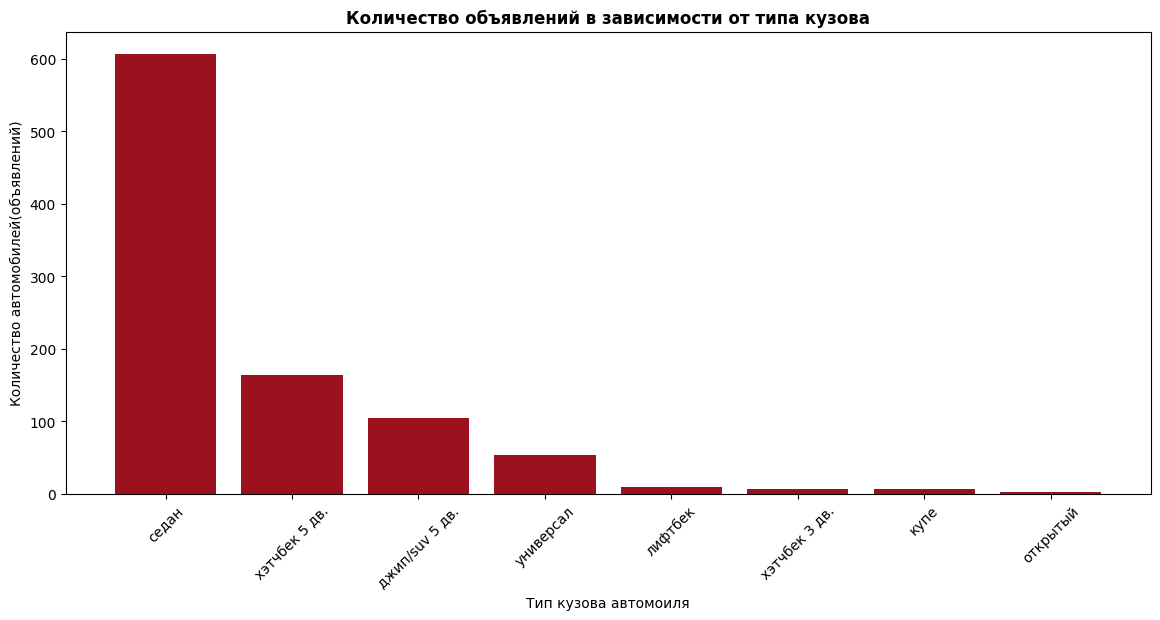

In [709]:
plt.figure(figsize = (14, 6))
plt.bar(body_table.index, body_table, color = '#9B111E')

plt.title('Количество объявлений в зависимости от типа кузова', fontweight = 'bold')
plt.xlabel('Тип кузова автомоиля')
plt.ylabel('Количество автомобилей(объявлений)')
plt.xticks(rotation = 45)

ТЕКСТИК

24.color - цвет конкретного автомобиля

In [710]:
color_table = df['color'].value_counts()
color_table

,count
color,
черный,360
белый,295
серый,234
серебристый,179
синий,131
красный,79
коричневый,35
зеленый,30
бордовый,26


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15],
 [Text(0, 0, 'черный'),
  Text(1, 0, 'белый'),
  Text(2, 0, 'серый'),
  Text(3, 0, 'серебристый'),
  Text(4, 0, 'синий'),
  Text(5, 0, 'красный'),
  Text(6, 0, 'коричневый'),
  Text(7, 0, 'зеленый'),
  Text(8, 0, 'бордовый'),
  Text(9, 0, 'голубой'),
  Text(10, 0, 'бежевый'),
  Text(11, 0, 'фиолетовый'),
  Text(12, 0, 'желтый'),
  Text(13, 0, 'золотистый'),
  Text(14, 0, 'оранжевый'),
  Text(15, 0, 'розовый')])

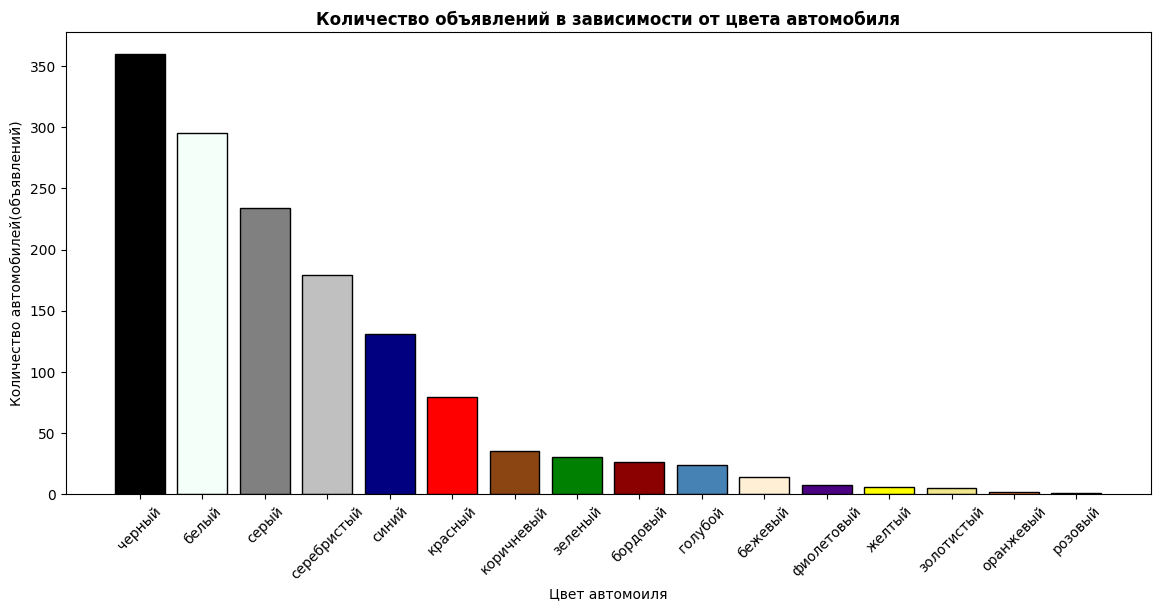

In [711]:
plt.figure(figsize = (14, 6))
plt.bar(color_table.index, color_table, color = ['#000000', '#F5FFFA', '#808080', '#C0C0C0', '#000080', '#FF0000', '#8B4513',
                                                 '#008000', '#8B0000', '#4682B4', '#FFEFD5', '#4B0082', '#FFFF00',
                                                 '#F0E68C', '#FF7F50', '#FF69B4'], edgecolor = 'black', linewidth = 1)

plt.title('Количество объявлений в зависимости от цвета автомобиля', fontweight = 'bold')
plt.xlabel('Цвет автомоиля')
plt.ylabel('Количество автомобилей(объявлений)')
plt.xticks(rotation = 45)

КАКОЙ-ТО ТЕКСТИК

25.wheel - расположение руля в конкретном автомобиле

In [712]:
wheel_table = df['wheel'].value_counts()
wheel_table

,count
wheel,
левый,1330
правый,137


Text(0.5, 1.0, 'Количество автомобилей в зависимости от расположения руля')

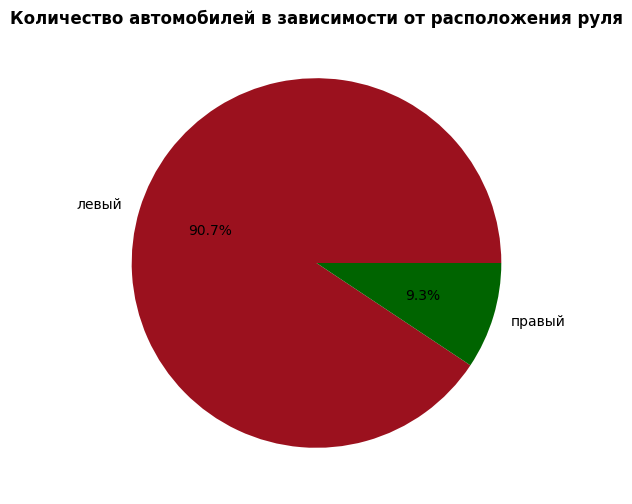

In [713]:
plt.figure(figsize = (14, 6))
colors = ['#9B111E', '#006400']
plt.pie(wheel_table, labels = wheel_table.index, colors = colors, autopct = '%.1f%%')
plt.title('Количество автомобилей в зависимости от расположения руля', fontweight = 'bold')

КАКОЙ-ТО ТЕКСТ

26.hp - количество лошадиных сил конкретного автомобиля

In [714]:
gp_table = pd.cut(df['hp'], bins = [0, 80, 110, 156, 200, 252, 300, 500, 2000],
    labels = ['до 80', '80 - 110', '110 - 156', '156 - 200', '200 – 252', '252 - 300', '300 - 500',
              '500+'])
gp_table = gp_table.value_counts().sort_index()

([0, 1, 2, 3, 4, 5, 6, 7],
 [Text(0, 0, 'до 80'),
  Text(1, 0, '80 - 110'),
  Text(2, 0, '110 - 156'),
  Text(3, 0, '156 - 200'),
  Text(4, 0, '200 – 252'),
  Text(5, 0, '252 - 300'),
  Text(6, 0, '300 - 500'),
  Text(7, 0, '500+')])

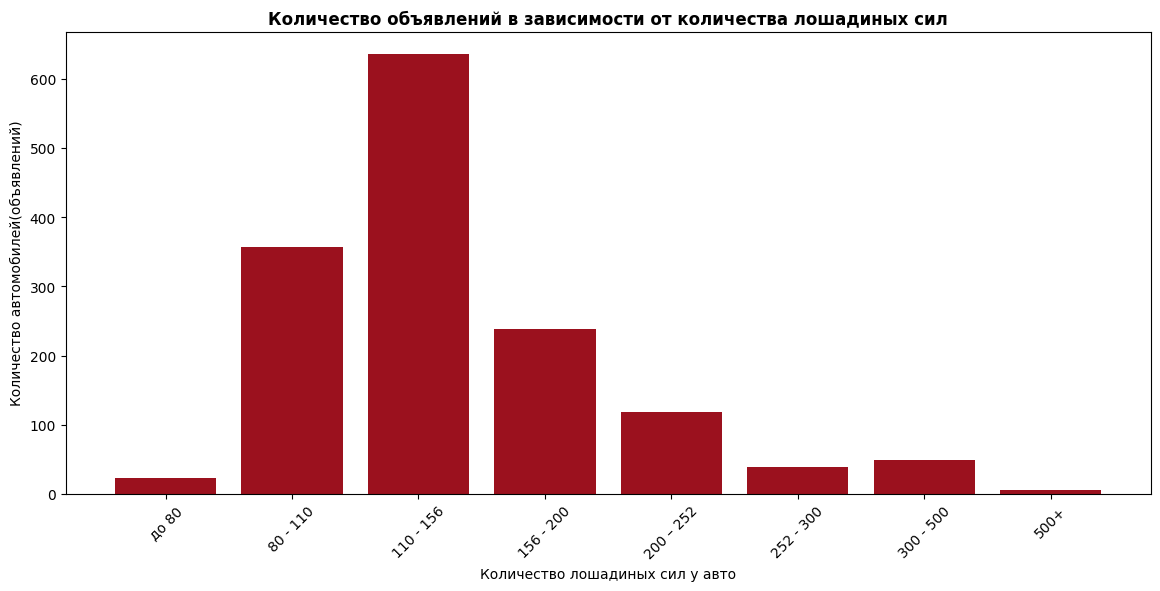

In [715]:
plt.figure(figsize = (14, 6))
plt.bar(gp_table.index, gp_table, color = '#9B111E')

plt.title('Количество объявлений в зависимости от количества лошадиных сил', fontweight = 'bold')
plt.xlabel('Количество лошадиных сил у авто')
plt.ylabel('Количество автомобилей(объявлений)')
plt.xticks(rotation = 45)

КАКОЙ_ТО ТЕКСТ

# Feature Engineering и корректировка значений

Сначала поработаем со столбцом engine. Вычленим из него два признака - это тип топлива и объем двигателя. Дополнительное оборудование в виде ГБО не будем включать в наш анализ


После поработаем с признаком пробега. Пока там существуют проспуски. Но в случае с машинами 2025 и 2026 года выпуска пропуски это не отсутсвие значения (NaN), а скорее отсутсвие пробега у авто. Так что у таких авто мы заменим нан на 0

In [716]:
df['engine'].sample(3)

,engine
155,"бензин, 1.5 л"
489,"бензин, 3.5 л"
949,"бензин, 2.0 л"


In [717]:
split_engine = df['engine'].str.split(',', expand = True)
split_engine.sample(4)

,0,1,2,3
1308,бензин,2.4 л,None,None
229,бензин,1.6 л,None,None
56,бензин,1.5 л,None,None
152,дизель,2.0 л,None,None


In [718]:
df['oil_type'] = split_engine[0]
df['oil_type'].sample(5)

,oil_type
571,дизель
1437,бензин
662,бензин
597,бензин
190,бензин


In [719]:
df['engine_volume'] = split_engine[1]
df['engine_volume'].sample(5)

,engine_volume
820,1.8 л
285,1.6 л
105,2.0 л
1378,1.6 л
1365,2.4 л


In [720]:
df.head(2)

,url,make,model,year,recalls_count,complaints_count,injuries,deaths,has_fire,has_crash,...,transmission,mileage,drive,body,color,wheel,hp,description,oil_type,engine_volume
0,https://auto.drom.ru/perm/hyundai/elantra/4754...,hyundai,elantra,2020,3,222,15,2,6,20,...,АКПП,88000.0,передний,седан,серый,левый,150.0,: Федеральная сеть автосалонов Crystal Motors ...,бензин,2.0 л
1,https://auto.drom.ru/vsevolozhsk/toyota/camry/...,toyota,camry,2019,6,361,18,0,1,21,...,АКПП,400000.0,передний,седан,белый,левый,150.0,: Машина ходовое вложение не требует Город : В...,бензин,2.0 л


In [721]:
df = df.drop('engine', axis = 1)

In [722]:
oil_table = df['oil_type'].value_counts()
oil_table

,count
oil_type,
бензин,1333
дизель,127
электро,4
1.8 л,1
2.0 л,1


Удалим ненужные строки, так как у них все равно пропуски в типе топлива

In [723]:
df = df.drop(df[df['oil_type'] == '1.8 л'].index)
df = df.drop(df[df['oil_type'] == '2.0 л'].index)

In [724]:
oil_table = df['oil_type'].value_counts()
oil_table

,count
oil_type,
бензин,1333
дизель,127
электро,4


Text(0, 0.5, 'Количество автомобилей(объявлений)')

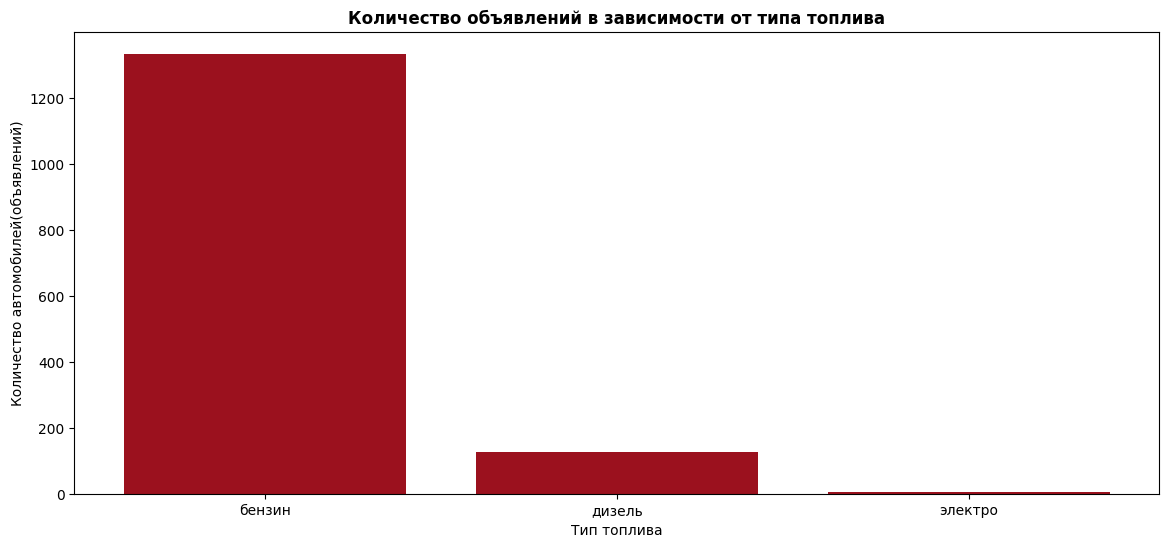

In [725]:
plt.figure(figsize = (14, 6))
plt.bar(oil_table.index, oil_table, color = '#9B111E')

plt.title('Количество объявлений в зависимости от типа топлива', fontweight = 'bold')
plt.xlabel('Тип топлива')
plt.ylabel('Количество автомобилей(объявлений)')

In [726]:
volume_table = df['engine_volume'].value_counts().sort_index()
volume_table

,count
engine_volume,
1.0 л,2
1.2 л,8
1.3 л,35
1.4 л,91
1.5 л,106
1.6 л,353
1.7 л,1
1.8 л,118
1.9 л,1


Text(0, 0.5, 'Количество автомобилей(объявлений)')

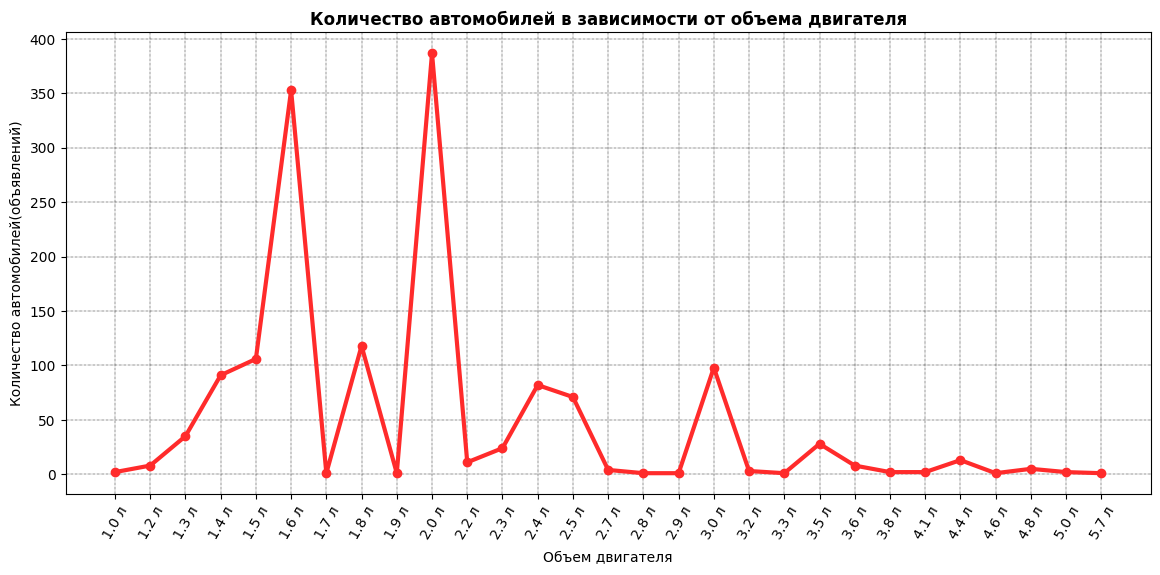

In [727]:
plt.figure(figsize = (14, 6))

plt.plot(volume_table.index, volume_table, color = '#FF2B2B', linewidth = 3, marker = 'o')
plt.grid(axis = 'both', color = 'black', linestyle = '-.', linewidth = 0.3)
plt.xticks(rotation = 60)
plt.title('Количество автомобилей в зависимости от объема двигателя', fontweight = 'bold')
plt.xlabel('Объем двигателя')
plt.ylabel('Количество автомобилей(объявлений)')

КАКОЙ-ТО ТЕКСТИК

Теперь у машин 2025 и 2026 года поменяем нан в пробеге на ноль

In [728]:
print('Авто 2025 года выпуска без пробега', df[(df['mileage'].isnull()) & (df['year'] == 2025)].shape)
print('Авто 2026 года выпуска без пробега', df[(df['mileage'].isnull()) & (df['year'] == 2026)].shape)

Авто 2025 года выпуска без пробега (13, 29)
Авто 2026 года выпуска без пробега (3, 29)


In [729]:
df.loc[(df['mileage'].isnull()) & (df['year'] == 2025), 'mileage'] = 0.0
df.loc[(df['mileage'].isnull()) & (df['year'] == 2026), 'mileage'] = 0.0

In [730]:
print('Авто 2025 года выпуска без пробега', df[(df['mileage'].isnull()) & (df['year'] == 2025)].shape)
print('Авто 2026 года выпуска без пробега', df[(df['mileage'].isnull()) & (df['year'] == 2026)].shape)

Авто 2025 года выпуска без пробега (0, 29)
Авто 2026 года выпуска без пробега (0, 29)


Теперь все должно быть отлично. Давайте перейдем к трудоемкому, но очень важному этапу

# Обработка пропусков в датасете

сразу давайте удалим ненужный нам признак model_exists

In [732]:
df = df.drop('model_exists', axis = 1)

In [733]:
df.isna().sum()

,0
url,0
make,0
model,0
year,0
recalls_count,0
complaints_count,0
injuries,0
deaths,0
has_fire,0
has_crash,0
